In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


%matplotlib inline


In [6]:
import csv

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv", quoting=csv.QUOTE_NONE, on_bad_lines='skip')


In [7]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
2,8,1077,24,Flattering,I love this dress. i usually get an xs but it ...,5,1,0,General,Dresses,Dresses
3,10,1077,53,Dress looks like it's made of cheap material,Dress runs small esp where the zipper area run...,3,0,14,General,Dresses,Dresses
4,11,1095,39,NaN,This dress is perfection! so pretty and flatte...,5,1,2,General Petite,Dresses,Dresses


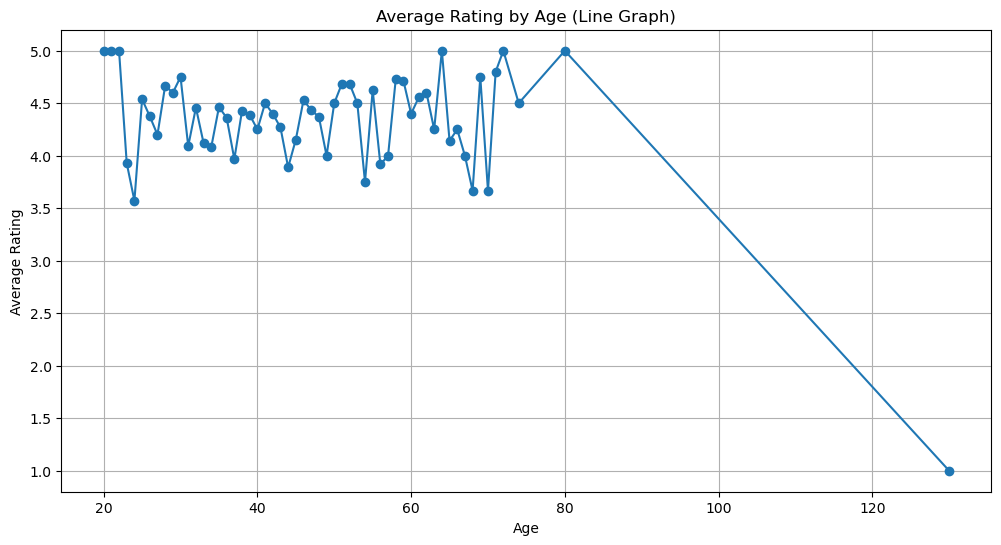

In [17]:
import pandas as pd
import matplotlib.pyplot as plt


df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')


df_clean = df.dropna(subset=['Age', 'Rating'])
age_rating = df_clean.groupby('Age')['Rating'].mean()
plt.figure(figsize=(12,6))
plt.plot(age_rating.index, age_rating.values, marker='o')
plt.title('Average Rating by Age (Line Graph)')
plt.xlabel('Age')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()


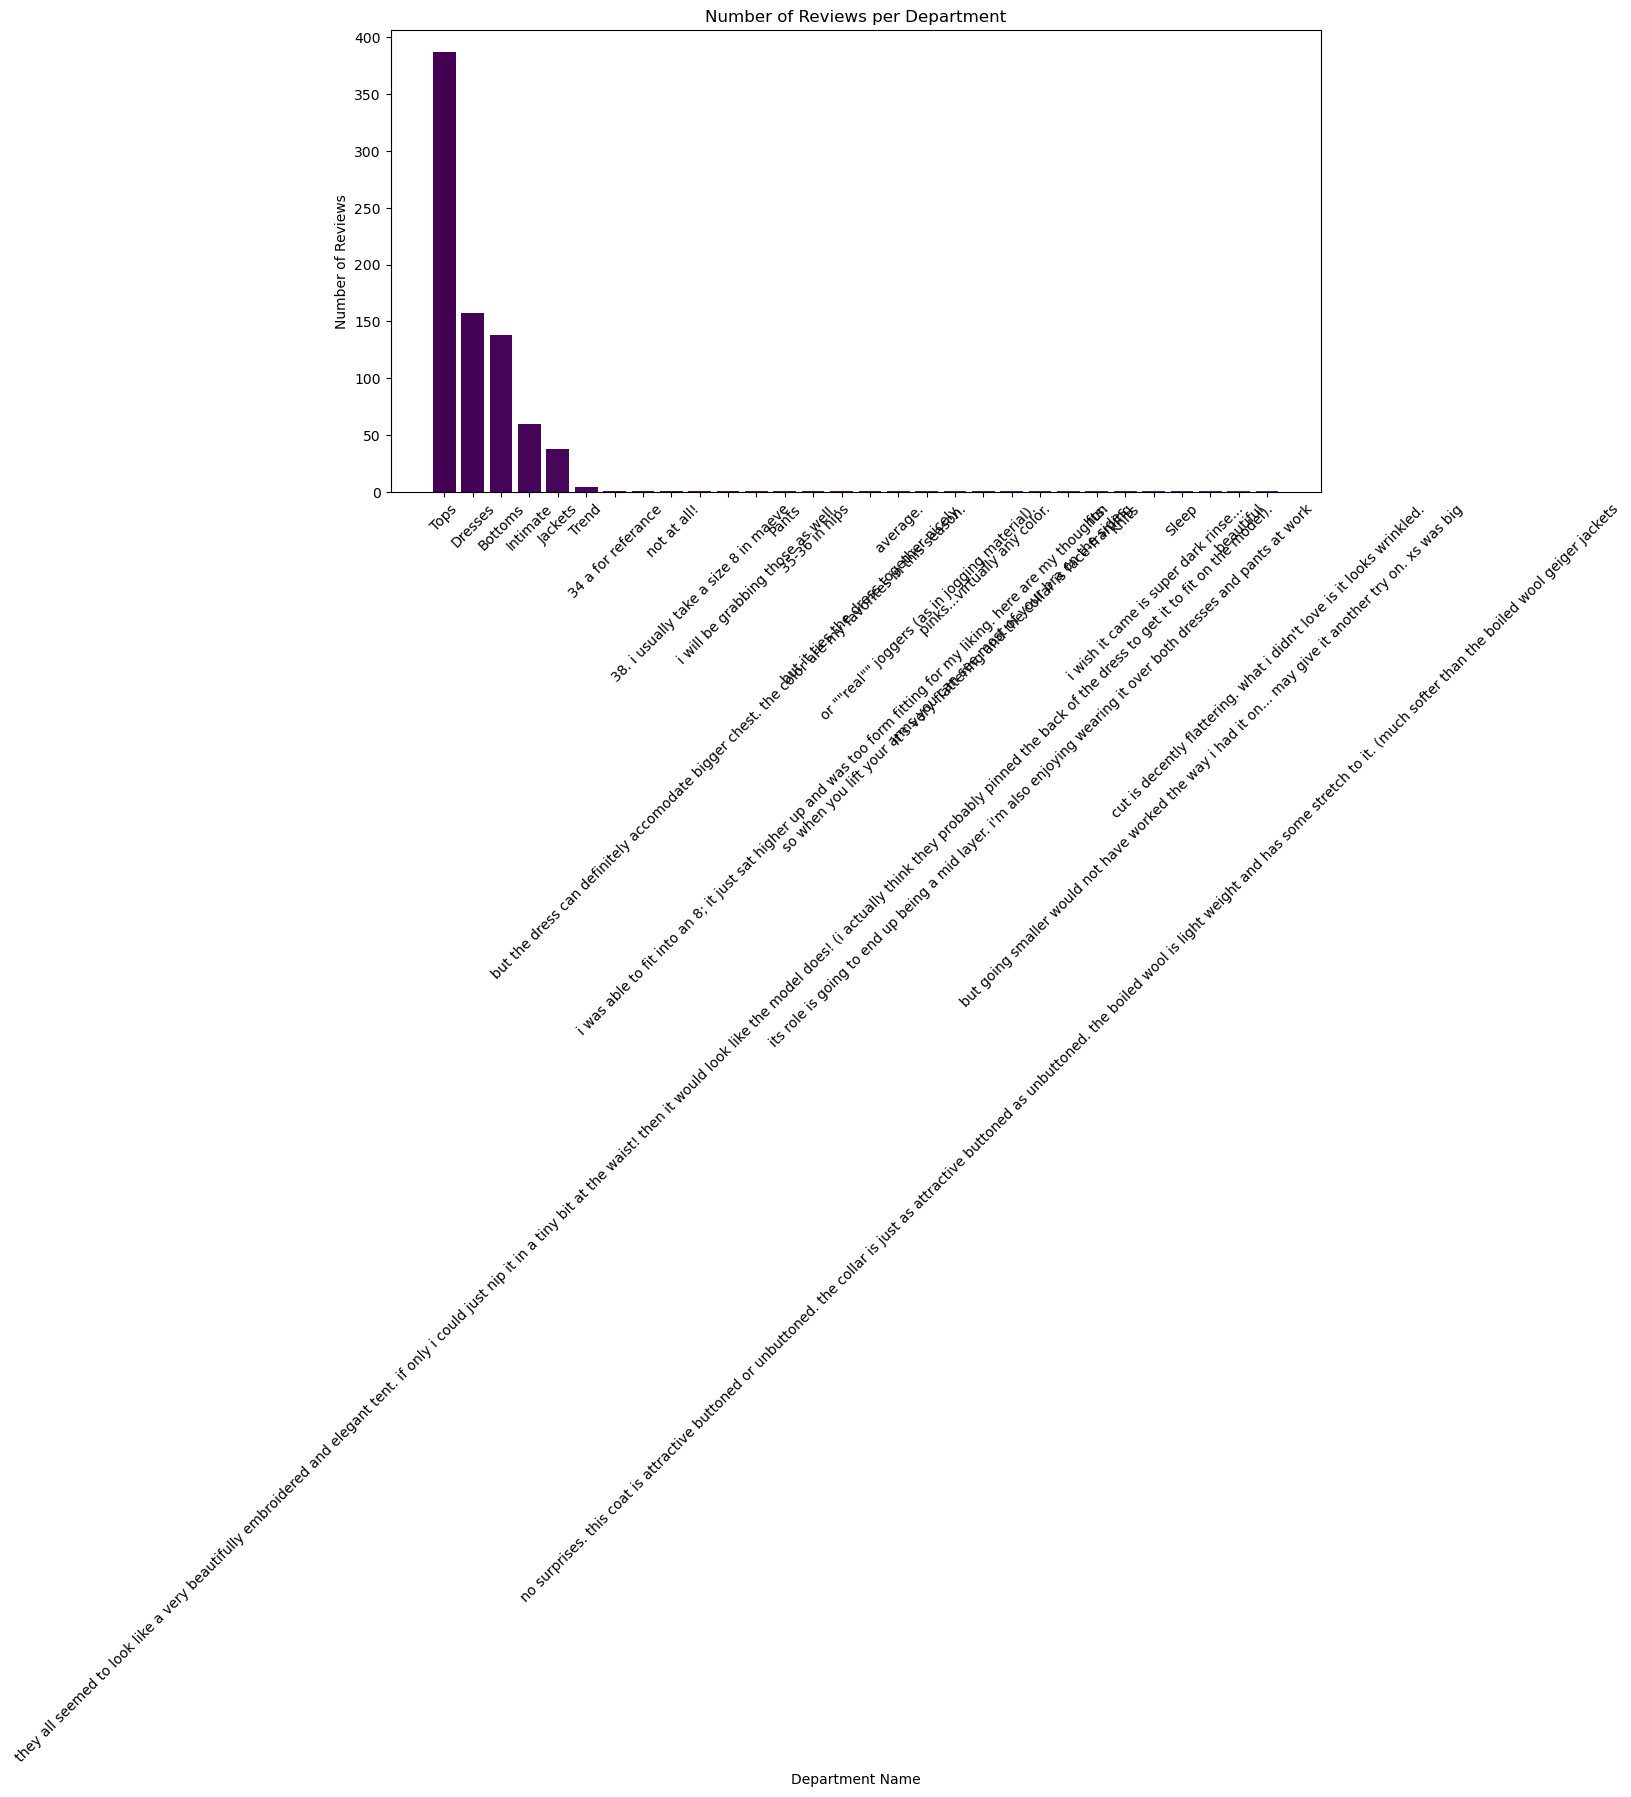

In [19]:
plt.figure(figsize=(12,6))
plt.bar(review_count.index, review_count.values, color=plt.cm.viridis(range(len(review_count))))
plt.title('Number of Reviews per Department')
plt.xlabel('Department Name')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.show()


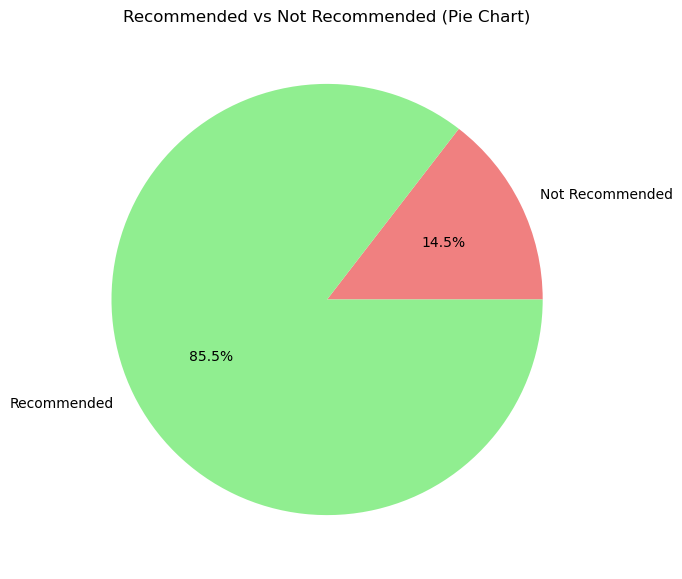

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
recommended_clean = pd.to_numeric(df['Recommended IND'], errors='coerce')
recommended_clean = recommended_clean[recommended_clean.isin([0,1])]

if recommended_clean.empty:
    print("Error: 'Recommended IND' sütununda 0 veya 1 değeri yok. Pie chart çizilemiyor.")
else:
    recommended_count = recommended_clean.value_counts().sort_index()  # 0 ve 1 sıralı
    plt.figure(figsize=(7,7))
    plt.pie(
        recommended_count.values,
        labels=['Not Recommended', 'Recommended'],
        autopct='%1.1f%%',
        colors=['lightcoral','lightgreen']
    )
    plt.title('Recommended vs Not Recommended (Pie Chart)')
    plt.show()


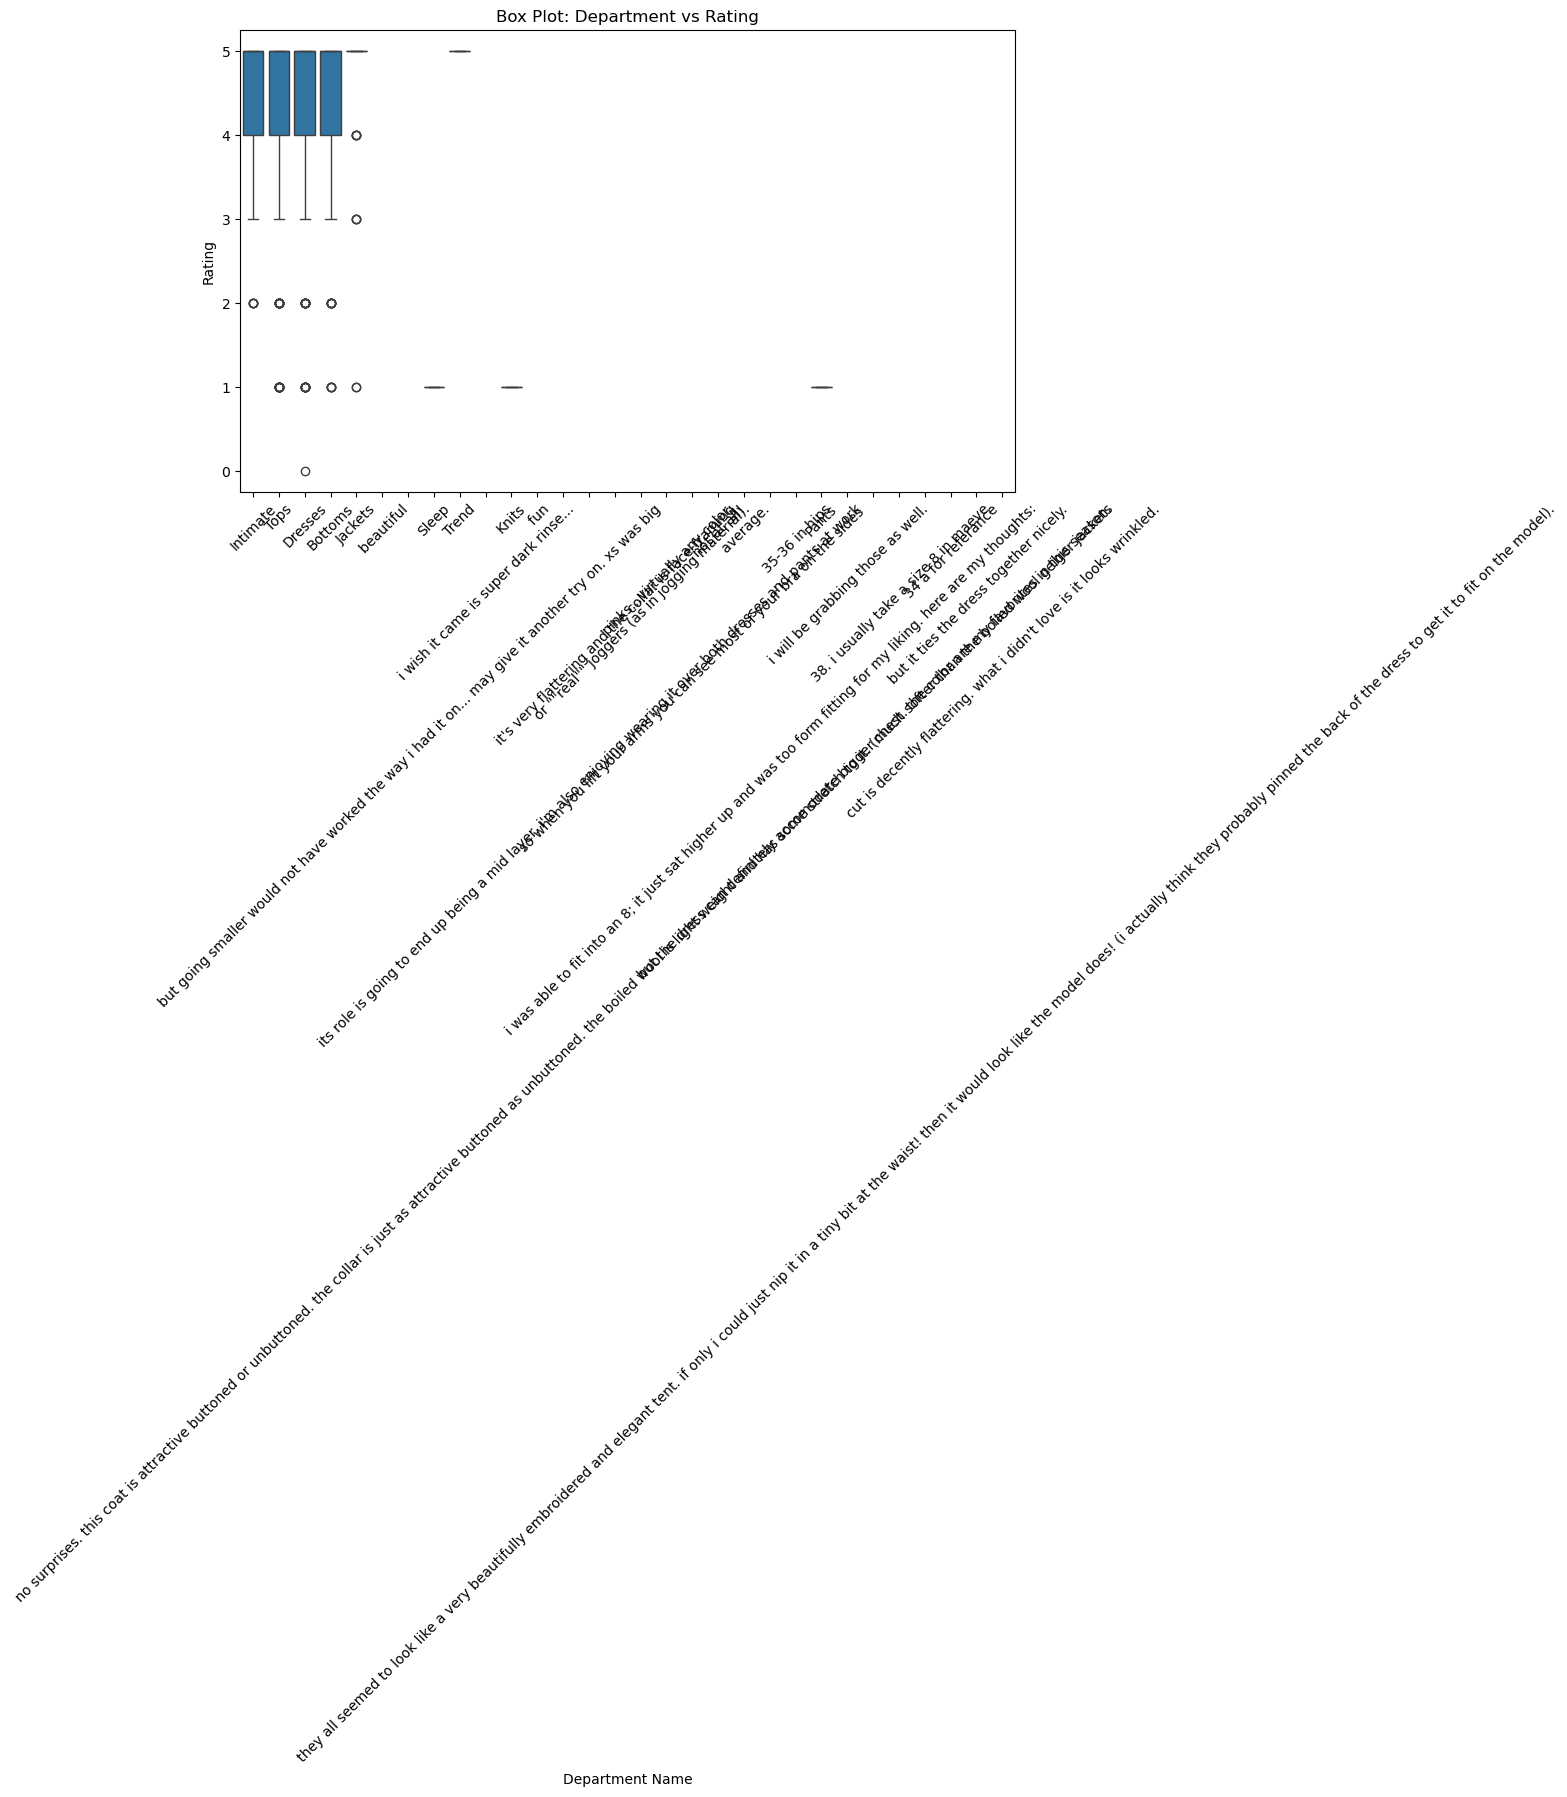

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x='Department Name', y='Rating', data=df)
plt.title('Box Plot: Department vs Rating')
plt.xticks(rotation=45)
plt.show()


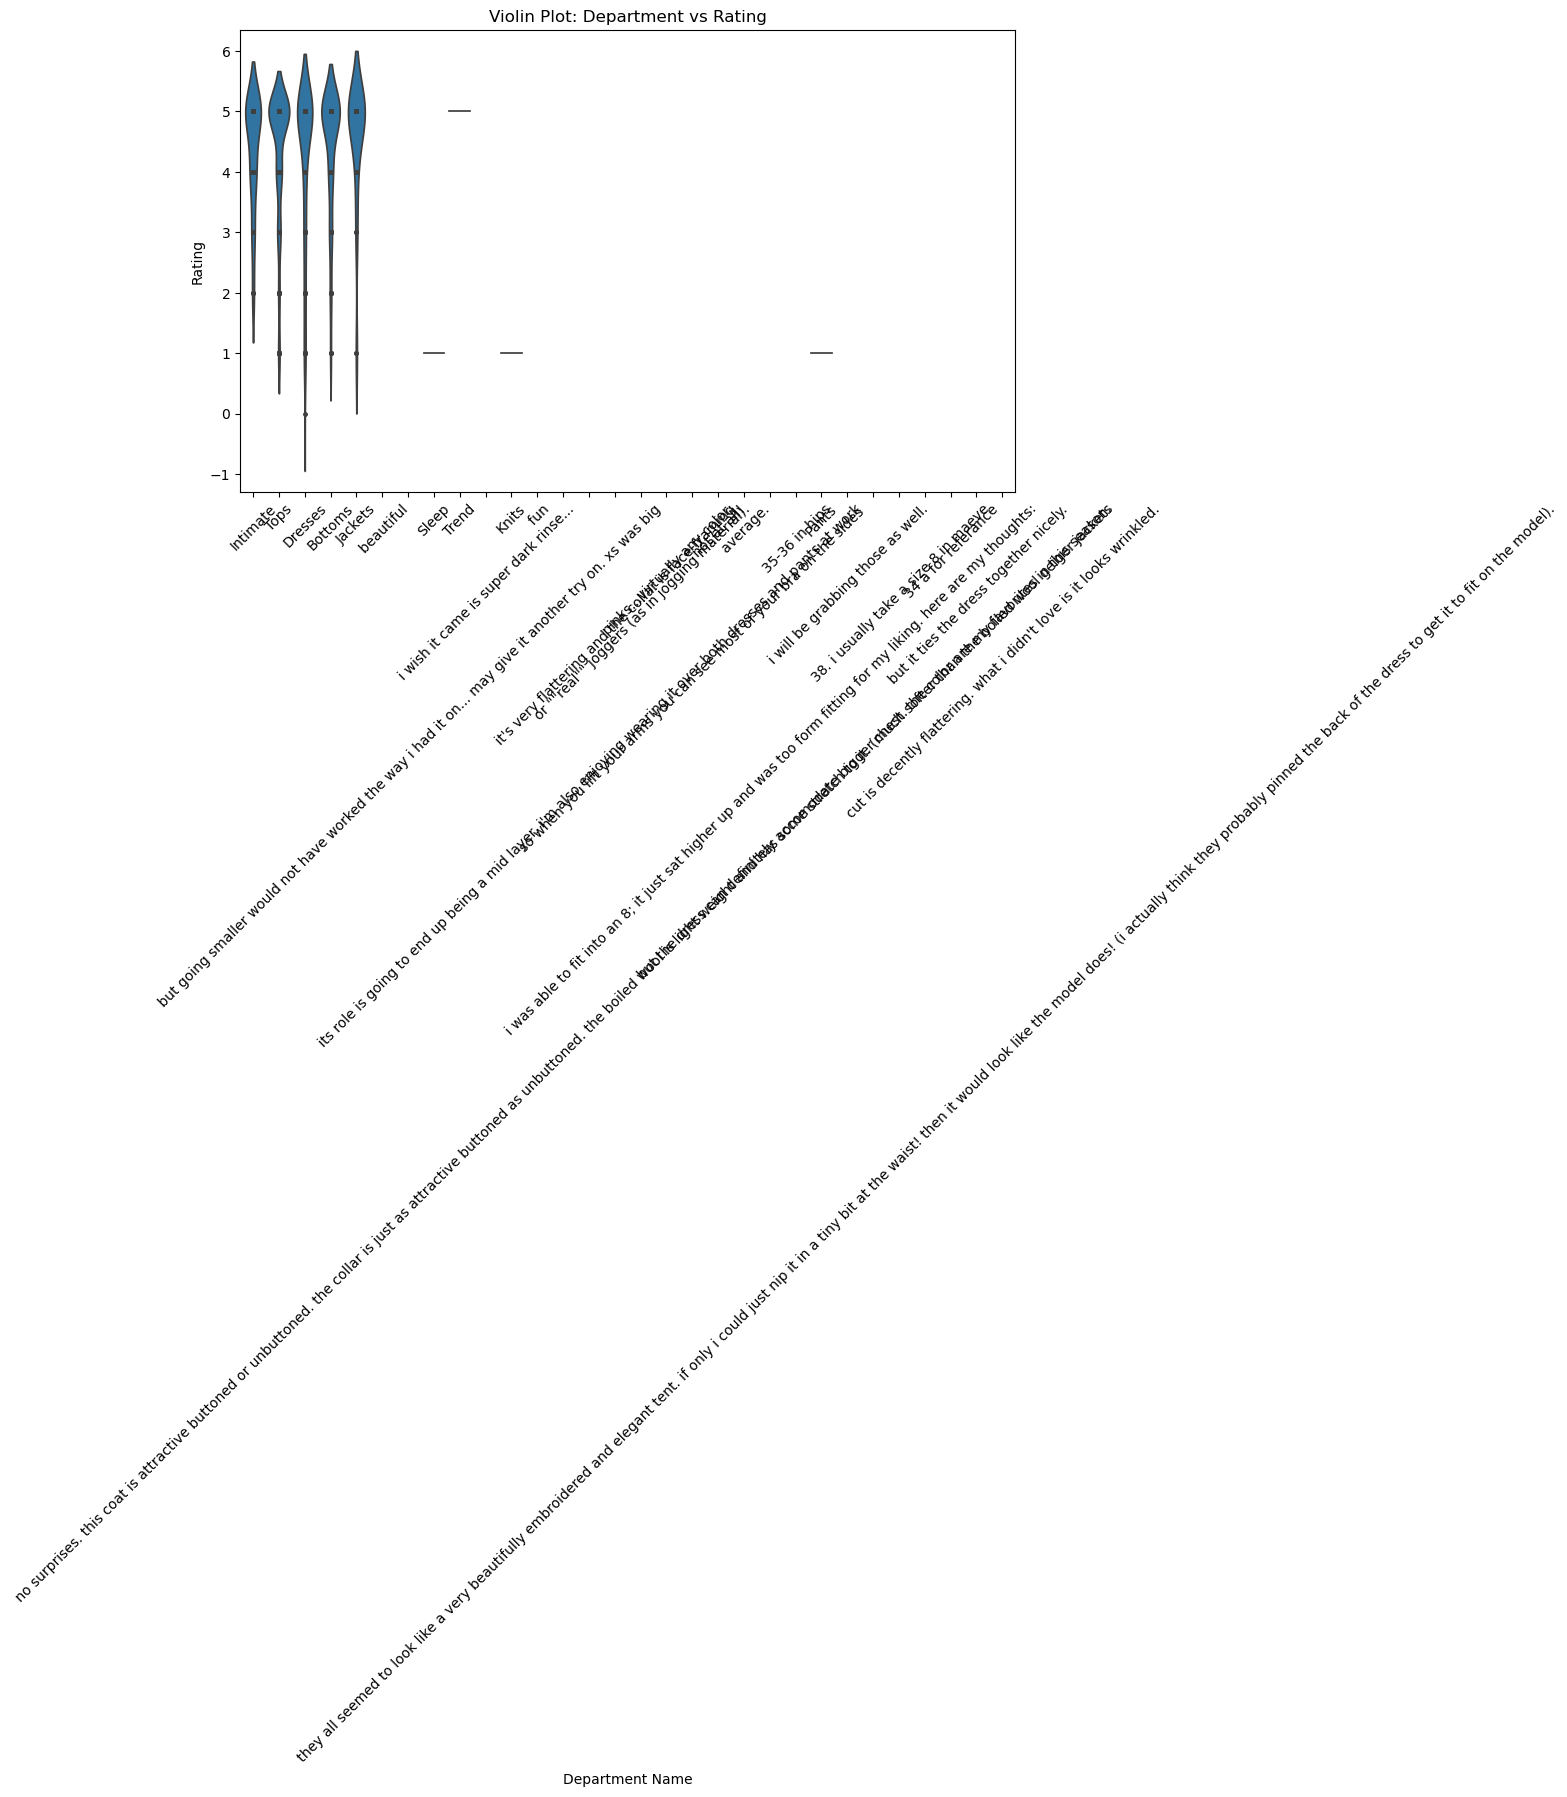

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.violinplot(x='Department Name', y='Rating', data=df, inner="point") 
plt.title('Violin Plot: Department vs Rating')
plt.xticks(rotation=45)
plt.show()
